### Train a Random Forest model

- Tune params 
- Evaluate performance

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction import DictVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

from utils.helper_functions import clean_data, model_splits

In [12]:
df = clean_data()
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,male,67.0,0,1,yes,private,urban,228.69,36.6,formerly_smoked,1
1,female,61.0,0,0,yes,self-employed,rural,202.21,28.1,never_smoked,1
2,male,80.0,0,1,yes,private,rural,105.92,32.5,never_smoked,1
3,female,49.0,0,0,yes,private,urban,171.23,34.4,smokes,1
4,female,79.0,1,0,yes,self-employed,rural,174.12,24.0,never_smoked,1


In [13]:
splits = model_splits(df)

In [14]:
splits = model_splits(df)

df_full_train = splits["df_full_train"]
df_train      = splits["df_train"]
df_val        = splits["df_val"]
df_test       = splits["df_test"]

y_train       = splits["y_train"]
y_val         = splits["y_val"]
y_test        = splits["y_test"]

In [15]:
train_dicts = df_train.to_dict(orient='records')
val_dicts = df_val.to_dict(orient='records')

dv = DictVectorizer(sparse=False)

X_train = dv.fit_transform(train_dicts)

X_val =  dv.transform(val_dicts)

In [16]:
rf = RandomForestClassifier(n_estimators=10)

rf.fit(X_train,y_train)

y_pred = rf.predict_proba(X_val)[:,1]

roc_auc_score(y_val, y_pred)

0.7358197556008147

,n_estimator,auc
0,10,0.686163
1,20,0.755168
2,30,0.780117
3,40,0.776247
4,50,0.773154
5,60,0.777393
6,70,0.777533
7,80,0.797543
8,90,0.804748
9,100,0.798256


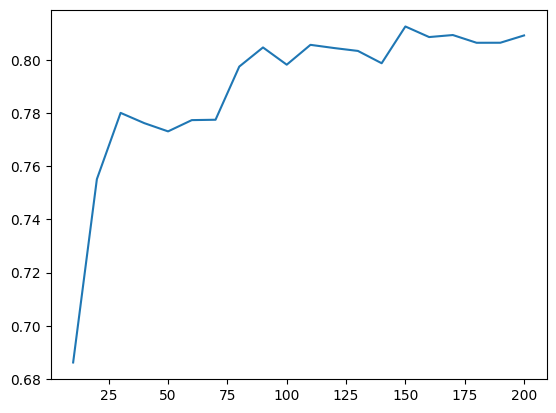

In [17]:
# range of n_estimator (10, 200)
# plot 

scores = []
for n in range(10, 201, 10):

    dv = DictVectorizer(sparse=False)

    train_dicts = df_train.to_dict(orient='records')
    X_train = dv.fit_transform(train_dicts)

    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)

    val_dicts = df_val.to_dict(orient='records')
    X_val =  dv.transform(val_dicts)

    y_pred = rf.predict_proba(X_val)[:,1]
  
    auc = roc_auc_score(y_val, y_pred)
    scores.append((n, auc))
    
scores_df = pd.DataFrame(scores, columns=['n_estimator', 'auc'])

plt.plot(scores_df.n_estimator, scores_df.auc)

scores_df

,n_estimator,max_depth,auc
27,80,3,0.843050
22,30,3,0.841408
28,90,3,0.841039
32,130,3,0.840962
23,40,3,0.840695
...,...,...,...
85,60,15,0.793432
86,70,15,0.793063
61,20,10,0.773396
60,10,10,0.751617


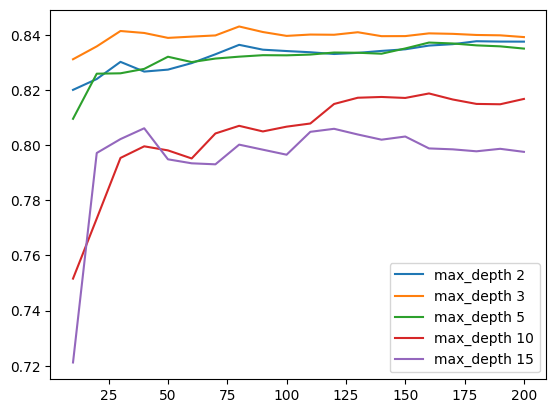

In [18]:
# list of max depth as outer loop 
# plot (loop max depth)
# Find max depth

max_depth = [2, 3, 5, 10, 15]
scores = []

for d in max_depth:

    for n in range(10, 201, 10):

        dv = DictVectorizer(sparse=False)

        train_dicts = df_train.to_dict(orient='records')
        X_train = dv.fit_transform(train_dicts)

        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=1)
        rf.fit(X_train, y_train)

        val_dicts = df_val.to_dict(orient='records')
        X_val =  dv.transform(val_dicts)

        y_pred = rf.predict_proba(X_val)[:,1]
    
        auc = roc_auc_score(y_val, y_pred)
        scores.append((n, d, auc))
        
scores_df = pd.DataFrame(scores, columns=['n_estimator', 'max_depth', 'auc'])

for d in max_depth:
    df_subset = scores_df[scores_df.max_depth == d]
    plt.plot(df_subset.n_estimator, df_subset.auc, label=f'max_depth {d}')

plt.legend()

scores_df.sort_values(by='auc', ascending=False)

,n_estimator,min_samples_leaf,auc
82,30,50,0.846079
83,40,50,0.844246
99,200,50,0.842668
98,190,50,0.842337
87,80,50,0.842159


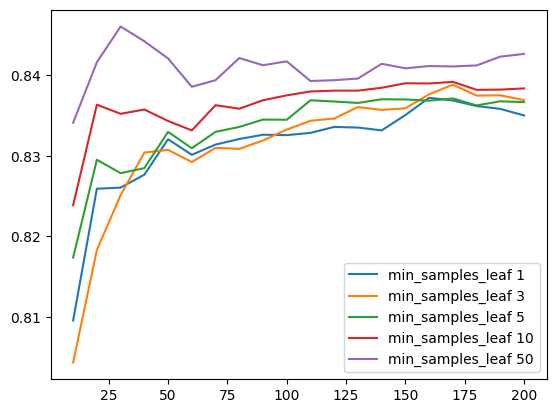

In [19]:
# repeat for min_leaf
# plot 

max_depth = 5

min_leaf_sample_values = [1, 3, 5, 10, 50]

scores = []

for m in min_leaf_sample_values:

    for n in range(10, 201, 10):

        dv = DictVectorizer(sparse=False)

        train_dicts = df_train.to_dict(orient='records')
        X_train = dv.fit_transform(train_dicts)

        rf = RandomForestClassifier(n_estimators=n, max_depth=max_depth, min_samples_leaf=m, random_state=1)
        rf.fit(X_train, y_train)

        val_dicts = df_val.to_dict(orient='records')
        X_val =  dv.transform(val_dicts)

        y_pred = rf.predict_proba(X_val)[:,1]
    
        auc = roc_auc_score(y_val, y_pred)
        scores.append((n, m, auc))
        
scores_df = pd.DataFrame(scores, columns=['n_estimator', 'min_samples_leaf', 'auc'])

for m in min_leaf_sample_values:
    df_subset = scores_df[scores_df.min_samples_leaf == m]
    plt.plot(df_subset.n_estimator, df_subset.auc, label=f'min_samples_leaf {m}')

plt.legend()

scores_df.sort_values(by='auc', ascending=False).head()



In [20]:
n_est = 200
min_leaf = 50
max_depth = 5

In [23]:
# Final model

dv = DictVectorizer(sparse=False)

train_dicts = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

rf = RandomForestClassifier(n_estimators=n_est, max_depth=max_depth, min_samples_leaf=min_leaf, random_state=1)
rf.fit(X_train, y_train)

val_dicts = df_val.to_dict(orient='records')
X_val =  dv.transform(val_dicts)

y_pred = rf.predict_proba(X_val)[:,1]
auc = roc_auc_score(y_val, y_pred)

print(f'Final model auc: {round(auc,4)}')

Final model auc: 0.8427
